In [1]:
import os
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Summary of cells

In [2]:
dat = pd.read_csv("data/NanoNASCseq.csv")

In [3]:
def divide(a, b):
    return np.nan if (b is None or b == 0) else a / b

In [4]:
# Cell reads and trimmed reads

cell_reads_list = []
cell_bases_list = []
trim_reads_list = []
for run, cell in dat[["Run", "Cell"]].values:
    cell_reads = np.nan
    cell_bases = np.nan
    trim_reads = np.nan
    path = "results/2_demux/4_trimmed/%s/%s/stats.tsv" % (run, cell)
    if os.path.exists(path):
        df = pd.read_csv(path, sep="\t")
        cell_reads = df["Total"].values[0]
        trim_reads = df["Pass"].values[0]
    path = "results/9_stat/3_depth/%s/%s.tsv" % (run, cell)
    if os.path.exists(path):
        with open(path) as f:
            try:
                cell_bases = int(list(f.readlines())[1].strip().split("\t")[2])
            except IndexError:
                print(path)
    cell_reads_list.append(cell_reads)
    cell_bases_list.append(cell_bases)
    trim_reads_list.append(trim_reads)
dat["Cell.Reads"] = cell_reads_list
dat["Cell.Bases"] = cell_bases_list
dat["Trimmed.Reads"] = trim_reads_list
dat["Trimmed.Ratio"] = dat["Trimmed.Reads"] / dat["Cell.Reads"]

results/9_stat/3_depth/20241122_Mix_3/20241122_Mix_3.C68.mESC_s4U_400uM_180min.tsv


In [5]:
# Mapped reads

mapped_reads_list = []
for run, cell in dat[["Run", "Cell"]].values:
    mapped_reads = np.nan
    path = "results/3_mapping/1_minimap2/%s/%s.flagstat" % (run, cell)
    if os.path.exists(path):
        mapped_reads = int(open(path).readlines()[7].split()[0])
    mapped_reads_list.append(mapped_reads)
dat["Mapped.Reads"] = mapped_reads_list
dat["Mapped.Ratio"] = dat["Mapped.Reads"] / dat["Trimmed.Reads"]

In [6]:
# Mitochondrion reads ratio

mito_ratio_list = []
for run, cell in dat[["Run", "Cell"]].values:
    mito_ratio = np.nan
    path = "results/9_stat/4_chrom_reads/%s/%s.tsv" % (run, cell)
    if os.path.exists(path):
        try:
            v1, v2 = 0, 0
            for line in open(path):
                chrom, count = line.strip("\n").split("\t")
                count = int(count)
                v1 += count
                if chrom == "chrM":
                    v2 = count
            mito_ratio = divide(v2, v1)
        except ValueError:
            print(path)
    mito_ratio_list.append(mito_ratio)
dat["Mito.Ratio"] = mito_ratio_list

In [7]:
# Filtered reads

filtered_reads_list = []
filtered_clip_reads_list = []
for run, cell in dat[["Run", "Cell"]].values:
    filtered_reads = np.nan
    filtered_clip_reads = np.nan
    path = "results/3_mapping/4_stat_clip/%s/%s.log" % (run, cell)
    if os.path.exists(path):
        lines = open(path).readlines()
        for i, line in enumerate(lines):
            if line.startswith("Input"):
                v1, v2 = lines[i + 1].split("\t")[:2]
                filtered_reads = int(v1)
                filtered_clip_reads = int(v2)
                break
    filtered_reads_list.append(filtered_reads)
    filtered_clip_reads_list.append(filtered_clip_reads)
dat["Filtered.Reads"] = filtered_reads_list
dat["Filtered.Ratio"] = dat["Filtered.Reads"] / dat["Mapped.Reads"]
dat["FilteredClip.Reads"] = filtered_clip_reads_list
dat["FilteredClip.Ratio"] = dat["FilteredClip.Reads"] / dat["Filtered.Reads"]

In [8]:
# Duplicate reads

umis1_list = []
umis2_list = []
for run, cell in dat[["Run", "Cell"]].values:
    path = "results/3_mapping/5_mark_duplicate/%s/%s.tsv" % (run, cell)
    umis1 = np.nan
    umis2 = np.nan
    if os.path.exists(path):
        d1 = pd.read_csv(path, sep="\t", header=0)
        umis1 = len(d1)
        umis2 = len(d1[d1["AllSize"] >= 2])
    umis1_list.append(umis1)
    umis2_list.append(umis2)
dat["UMIs"] = umis1_list
dat["mrUMIs"] = umis2_list
dat["Duplicate.Reads"] = dat["FilteredClip.Reads"] - dat["UMIs"]
dat["Duplicate.Ratio"] = dat["Duplicate.Reads"] / dat["FilteredClip.Reads"]
dat["Unique.Reads"] = dat["UMIs"]

In [9]:
# Detected genes

genes_list = []
for run, cell in dat[["Run", "Cell"]].values:
    genes = np.nan
    path = "results/5_expression/4_quant_genes/min_read_1_min_tc_1/%s/%s.tsv" % (run, cell)
    if os.path.exists(path):
        d = pd.read_csv(path, sep="\t", header=0, index_col=0)
        d = d[d["Total"] > 0]
        genes = len(set(filter(lambda x: "_" not in x, d.index)))
    genes_list.append(genes)
dat["Genes"] = genes_list

In [10]:
# Detected isoforms

sc_list = set(['full-splice_match', 'incomplete-splice_match', 'novel_in_catalog', 'novel_not_in_catalog'])
isoforms1_list = []
isoforms2_list = []
for run, cell in dat[["Run", "Cell"]].values:
    isoforms1 = np.nan # number of assemblied isoforms
    isoforms2 = np.nan # number of known isoforms
    path = "results/6_assembly/2_sqanti3/%s/%s/%s_classification.txt" % (run, cell, cell)
    if os.path.exists(path):
        d = pd.read_csv(path, sep="\t", header=0, index_col=0)
        isoforms1 = len(d)
        d = d[[sc in sc_list for sc in d["structural_category"]]]
        isoforms2 = len(d)
    isoforms1_list.append(isoforms1)
    isoforms2_list.append(isoforms2)
dat["Isoforms.Assembled"] = isoforms1_list
dat["Isoforms.Known"] = isoforms2_list

In [11]:
# Mismatch ratios

mtypes = []
for base1 in "ACGT":
    for base2 in "ACGT":
        if base1 != base2:
            mtypes.append("%s%s" % (base1, base2))
ratios = dict()
for mtype in mtypes:
    ratios[mtype] = list()
for run, cell in dat[["Run", "Cell"]].values:
    path = "results/4_mismatch/4_ratio_consensus/%s/%s.tsv" % (run, cell)
    if os.path.exists(path):
        df = pd.read_csv(path, sep="\t", index_col=0)
        for mtype in mtypes:
            ratios[mtype].append(df.loc[mtype]["Ratio"])
    else:
        for mtype in mtypes:
            ratios[mtype].append(np.nan)
for mtype in mtypes:
    dat["%s.Ratio" % mtype] = ratios[mtype]

In [12]:
# Pe and Pc

pe_list = []
pc_list = []
for run, cell in dat[["Run", "Cell"]].values:
    pe = np.nan
    pc = np.nan
    path = "results/9_stat/2_snr_corrected/%s/%s.snr.csv" % (run, cell)
    if os.path.exists(path):
        d = pd.read_csv(path)
        pe, pc = d["Pe"].values[0], d["Pc"].values[0]
    pe_list.append(pe)    
    pc_list.append(pc)
dat["Pe"] = pe_list
dat["Pc"] = pc_list
dat["SNR"] = dat["Pc"] / dat["Pe"]

In [13]:
# New UMIs

nascent_umis_list = []
for run, cell in dat[["Run", "Cell"]].values:
    nascent_umis = np.nan
    path = "results/4_mismatch/4_ratio_consensus/%s/%s.events.tsv" % (run, cell)
    if os.path.exists(path):
        d = pd.read_csv(path, sep="\t", index_col=0)
        d = d[(d["Size"] >= 2) & (d["T-C"] >= 2)]
        nascent_umis = len(d)
    nascent_umis_list.append(nascent_umis)
dat["mrUMIs.New"] = nascent_umis_list
dat["mrUMIs.New.Ratio"] = dat["mrUMIs.New"] / dat["mrUMIs"]

In [14]:
# New gene number

genes_list = []
nascent_genes_list = []
for run, cell in dat[["Run", "Cell"]].values:
    genes = np.nan
    nascent_genes = np.nan
    path = "results/5_expression/4_quant_genes/min_read_2_min_tc_2/%s/%s.tsv" % (run, cell)
    if os.path.exists(path):
        d = pd.read_csv(path, sep="\t", header=0, index_col=0)
        d = d[d["Total"] > 0]
        genes = len(set(filter(lambda x: "_" not in x, d.index)))
        if "New" in d.columns:
            d = d[d["New"] > 0]
        elif "Nascent" in d.columns:
            d = d[d["Nascent"] > 0]
        else:
            assert False
        nascent_genes = len(set(filter(lambda x: "_" not in x, d.index)))
    genes_list.append(genes)
    nascent_genes_list.append(nascent_genes)
dat["mrGenes"] = genes_list
dat["mrGenes.New"] = nascent_genes_list

In [15]:
dat.to_csv("reports/NanoNASCseq_Summary.csv", index=False)

# Summary of runs

In [64]:
d = pd.read_csv("reports/NanoNASCseq_Summary.csv", index_col=0)

rows = []
for run, d2 in sorted(d.groupby(by="Run")):
    counter1 = defaultdict(int)
    counter2 = defaultdict(int)
    counter3 = defaultdict(int)
    for species, ct, s4u, time, actd, phase, iaa, stage in d2[["Species", "CellType", "s4U", "Time", "ActD", "Phase", "IAA", "Stage"]].values:
        counter1[species] += 1
        counter2[ct] += 1
        items = []
        items.append(ct)
        if isinstance(phase, str):
            items.append(phase)
        if not np.isnan(iaa):
            items.append("IAA_%dh" % iaa)
        if isinstance(stage, str):
            items.append(stage)
        if not np.isnan(actd):
            items.append("Actd_%dh" % actd)
        if time >= 1:
            items.append("s4U_%duM_%dh" % (s4u, time))
        else:
            items.append("s4U_%duM_%dmin" % (s4u, time*60))
        k = ".".join(items)
        counter3[k] += 1
    rows.append([
        run, len(d2),
        ";".join(["%s:%d" % (k, v) for k, v in sorted(counter1.items())]),
        ";".join(["%s:%d" % (k, v) for k, v in sorted(counter2.items())]),
        ";".join(["%s:%d" % (k, v) for k, v in sorted(counter3.items())]),
    ])
m = pd.DataFrame(rows)
m.columns = ["Run", "Cells", "Species", "CellTypes", "Conditions"]
m.to_csv("reports/NanoNASCseq_Runs.csv", index=False)

# Cell number of conditions

In [71]:
d = pd.read_csv("reports/NanoNASCseq_Summary.csv", index_col=0)

counter1 = defaultdict(int) # All
counter2 = defaultdict(int) # Pass
for run, d2 in sorted(d.groupby(by="Run")):
    for species, ct, s4u, time, actd, phase, iaa, stage, umi in d2[["Species", "CellType", "s4U", "Time", "ActD", "Phase", "IAA", "Stage", "UMIs"]].values:
        items = [ct]       
        if isinstance(phase, str):
            items.append(phase)
        if not np.isnan(iaa):
            items.append("IAA_%dh" % iaa)
        if isinstance(stage, str):
            items.append(stage)
        if not np.isnan(actd):
            items.append("Actd_%dh" % actd)
        if time >= 1:
            items.append("s4U_%duM_%dh" % (s4u, time))
        else:
            items.append("s4U_%duM_%dmin" % (s4u, time*60))
        k = (".".join(items), ct, s4u, time)
        counter1[k] += 1
        if umi > 5000:
            counter2[k] += 1

rows = []
for k, v1 in sorted(counter1.items()):
    v2 = counter2[k]
    name, ct, s4u, time = k
    rows.append([name, ct, s4u, time, v1, v2])
m = pd.DataFrame(rows, columns=["Name", "CellType", "s4U", "Time", "Cells", "Cells[UMI>5000]"])
m.to_csv("reports/NanoNASCseq_Cell_Number.csv", index=False)

In [48]:
# d = pd.read_csv("../0_Analysis/05_mouse_blastocyst/01_clustering/results/h5ad_consensus/Blastocyst.gene_based.obs.csv")

# counter1 = defaultdict(int) # All
# counter2 = defaultdict(int) # Pass
# for run, d2 in sorted(d.groupby(by="Run")):
#     for species, ct, s4u, time, actd, umi in d2[["Species", "CellType_Consensus", "s4U", "Time", "ActD", "UMIs"]].values:
#         items = []
#         items.append(ct)
#         if not np.isnan(actd):
#             items.append("Actd_%dh" % actd)
#         if time >= 1:
#             items.append("s4U_%duM_%dh" % (s4u, time))
#         else:
#             items.append("s4U_%duM_%dmin" % (s4u, time*60))
#         k = ".".join(items)
#         counter1[k] += 1
#         if umi > 5000:
#             counter2[k] += 1  

# rows = []
# for k, v1 in sorted(counter1.items()):
#     v2 = counter2[k]
#     s4u = int(k.split(".")[-1].split("_")[1][:-2])
#     time = k.split(".")[-1].split("_")[2]
#     if time.endswith("h"):
#         time = int(time[:-1])
#     else:
#         time = int(time[:-3])/60
#     rows.append([k, k.split(".")[0], s4u, time, v1, v2])
# m = pd.DataFrame(rows, columns=["Name", "CellType", "s4U", "Time", "Cells", "Cells[UMI>5000]"])
# m.to_csv("reports/NanoNASCseq_Cell_Number.MouseBlastocyst.csv", index=False)

# Unnamed

In [48]:
# dat = pd.read_csv("reports/NanoNASCseq_Summary.csv")

# K562
rows = []
d = dat[(dat["CellLine"] == "K562") & (dat["ActD"].isna())]
for (s4u, time), d2 in d.groupby(by=["s4U", "Time"]):
    d3 = d2[d2['UMIs'] > 5000]
    rows.append(["K562", s4u, time, len(d2), len(d3)])

d = dat[(dat["CellLine"] == "K562") & (~dat["ActD"].isna())]
for (s4u, time, actd), d2 in d.groupby(by=["s4U", "Time", 'ActD']):
    d3 = d2[d2['UMIs'] > 5000]
    rows.append(["K562_ActD_%dh" % actd, s4u, time, len(d2), len(d3)])

d = dat[(dat["CellLine"] == "mESC") & (dat["ActD"].isna())]
for (s4u, time), d2 in d.groupby(by=["s4U", "Time"]):
    d3 = d2[d2['UMIs'] > 5000]
    rows.append(["mESC", s4u, time, len(d2), len(d3)])


d = dat[(dat["CellLine"] == "K562_FUCCI") & (dat["ActD"].isna())]
for (s4u, time, phase), d2 in d.groupby(by=["s4U", "Time", 'Phase']):
    d3 = d2[d2['UMIs'] > 5000]
    rows.append(["K562_FUCCI_%s" % phase, s4u, time, len(d2), len(d3)])

d = dat[(dat["CellLine"] == "mESC_EXOSC2") & (dat["ActD"].isna())]
for (s4u, time, iaa), d2 in d.groupby(by=["s4U", "Time", 'IAA']):
    d3 = d2[d2['UMIs'] > 5000]
    rows.append(["mESC_EXOSC2_IAA_%dh" % iaa, s4u, time, len(d2), len(d3)])
    
m = pd.DataFrame(rows, columns=["Cell Line", 's4U', 'Time', 'Cells', 'Cells [UMIs > 5000]'])
m

,Cell Line,s4U,Time,Cells,Cells [UMIs > 5000]
0,K562,0,3.00,196,190
1,K562,50,0.25,32,32
2,K562,50,0.50,51,51
3,K562,50,1.00,41,41
4,K562,50,2.00,44,44
5,K562,50,3.00,188,179
6,K562,100,3.00,19,19
7,K562,200,3.00,22,11
8,K562,400,3.00,26,17
9,K562,500,3.00,26,23


In [43]:
dat.columns

Index(['Cell', 'Run', 'Barcode', 'Species', 's4U', 'Time', 'ActD', 'Group',
       'CellLine', 'Stage', 'Platform', 'Label', 'UMI', 'Cells', 'LibStruct',
       'Remark', 'Cell.Reads', 'Cell.Bases', 'Trimmed.Reads', 'Trimmed.Ratio',
       'Mapped.Reads', 'Mapped.Ratio', 'Mito.Ratio', 'Filtered.Reads',
       'Filtered.Ratio', 'FilteredClip.Reads', 'FilteredClip.Ratio', 'UMIs',
       'mrUMIs', 'Duplicate.Reads', 'Duplicate.Ratio', 'Unique.Reads', 'Genes',
       'Isoforms.Assembled', 'Isoforms.Known', 'AC.Ratio', 'AG.Ratio',
       'AT.Ratio', 'CA.Ratio', 'CG.Ratio', 'CT.Ratio', 'GA.Ratio', 'GC.Ratio',
       'GT.Ratio', 'TA.Ratio', 'TC.Ratio', 'TG.Ratio', 'Pe', 'Pc', 'SNR',
       'mrUMIs.New', 'mrUMIs.New.Ratio', 'mrGenes', 'mrGenes.New', 'Phase'],
      dtype='object')

CellLine: K562
Cells: 2186
Mean: 389.6669261193961
Median: 339.395959
CellLine: mESC
Cells: 1850
Mean: 362.09395900756755
Median: 326.6266325


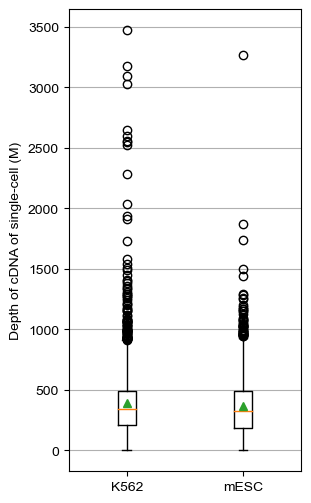

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
d = pd.read_csv("reports/NanoNASCseq_Summary.csv")
array = []
for cl in ["K562", "mESC"]:
    vs = d[d["CellLine"] == cl]["Cell.Bases"]
    vs = vs[~np.isnan(vs)]
    vs = vs/1e6
    print("CellLine:", cl)
    print("Cells:", len(vs))
    print("Mean:", np.mean(vs))
    print("Median:", np.median(vs))
    array.append(vs)
plt.figure(figsize=(3, 6))
plt.boxplot(array, showfliers=True, showmeans=True)
plt.grid(axis="y")
plt.ylabel("Depth of cDNA of single-cell (M)")
plt.xticks([1, 2], ["K562", "mESC"])
plt.show()

In [92]:
print(len(dat))
dat = dat[(~dat["Group"].isna())]
print(len(dat))

cell2sra = dict()
tmp = pd.read_csv("../0_Analysis/99_upload/table_download.tsv", sep="\t")
for sra, fq in tmp[["Accession", "SRA.filename"]].values:
    cell = fq[:-9]
    cell2sra[cell] = sra
dat["SRA"] = [cell2sra[cell] for cell in dat["Cell"]]
dat.to_csv("reports/FLAIRseq_Summary.tsv", index=False, sep="\t")

4470
4470


# Report summary of runs

In [19]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
array = []
for path in sorted(glob.glob("results/01_qc/03_library_summary/*.tsv")):
    d = pd.read_csv(path, sep="\t", index_col=0)
    array.append(d)
m = pd.concat(array)

In [10]:
ds = []
for run in m.index:
    path = "results/02_demux/03_splitted/%s/stats.tsv" % run
    d = pd.read_csv(path, sep="\t")
    d.index = [run]
    d.index.name = "Run"
    d = d[["Total", "TooShort", "Unknown", "Conflict", "Assigned"]]
    d.columns = ["TotalReads", "TooShortReads", "UnknownCellReads", "ConflictCellReads", "AssignedCellReads"]
    ds.append(d)
m2 = pd.concat(ds)
m = m.merge(m2, left_index=True, right_index=True, how="left")

In [11]:
ds = []
for run in m.index:
    ds2 = []
    for path2 in sorted(glob.glob("results/02_demux/04_trimmed/%s/*/stats.tsv" % run)):
        cell = path2.split("/")[-2]
        d = pd.read_csv(path2 ,sep="\t")
        d = d[["Total", "RawTooShort", "NoTSO",
               "IsChimeric", "NoDirection", "NoAnchor", 
               "NoUMI", "TrimTooShort", "Pass"]]
        d.columns = ["CellReads", "RawTooShort", "NoTSO",
                     "IsChimeric", "NoDirection", "NoAnchor", 
                     "NoUMI", "TrimTooShort", "TrimmedReads"]
        d.index = [cell]
        d.index.name = "Cell"
        ds2.append(d)
    d2 = pd.concat(ds2)
    d = pd.DataFrame(d2.sum()).T
    d.index = [run]
    d.index.name = "Run"
    ds.append(d)
m2 = pd.concat(ds)
m = m.merge(m2, left_index=True, right_index=True)

In [12]:
ds = []
for run in m.index:
    n = 0
    for path2 in sorted(glob.glob("results/03_mapping/04_stat_clip/%s/*.tsv" % run)):
        d2 = pd.read_csv(path2, sep="\t")
        n += sum(d2["Count"])
    d = pd.DataFrame([n], columns=["MappedFilteredReads"])
    d.index = [run]
    d.index.name = "Run"
    ds.append(d)
m2 = pd.concat(ds)
m = m.merge(m2, left_index=True, right_index=True)
m["UnmappedOrFailedReads"] = m["TrimmedReads"] - m["MappedFilteredReads"]

In [13]:
vs = []
for run in m.index:
    v = 0
    for path in sorted(glob.glob("results/09_stat/03_depth/%s/*.tsv" % run)):
        v += pd.read_csv(path, sep="\t")["Bases"].values[0]
    vs.append(v)
m["CellBases"] = vs
m["CellBasesRatio"] = m["CellBases"] / m["TotalBase"]

In [14]:
m.to_csv("reports/Summary_of_runs.csv")

# Plot summary of RUN

In [24]:
m = pd.read_csv("reports/Summary_of_runs.csv", index_col=0)

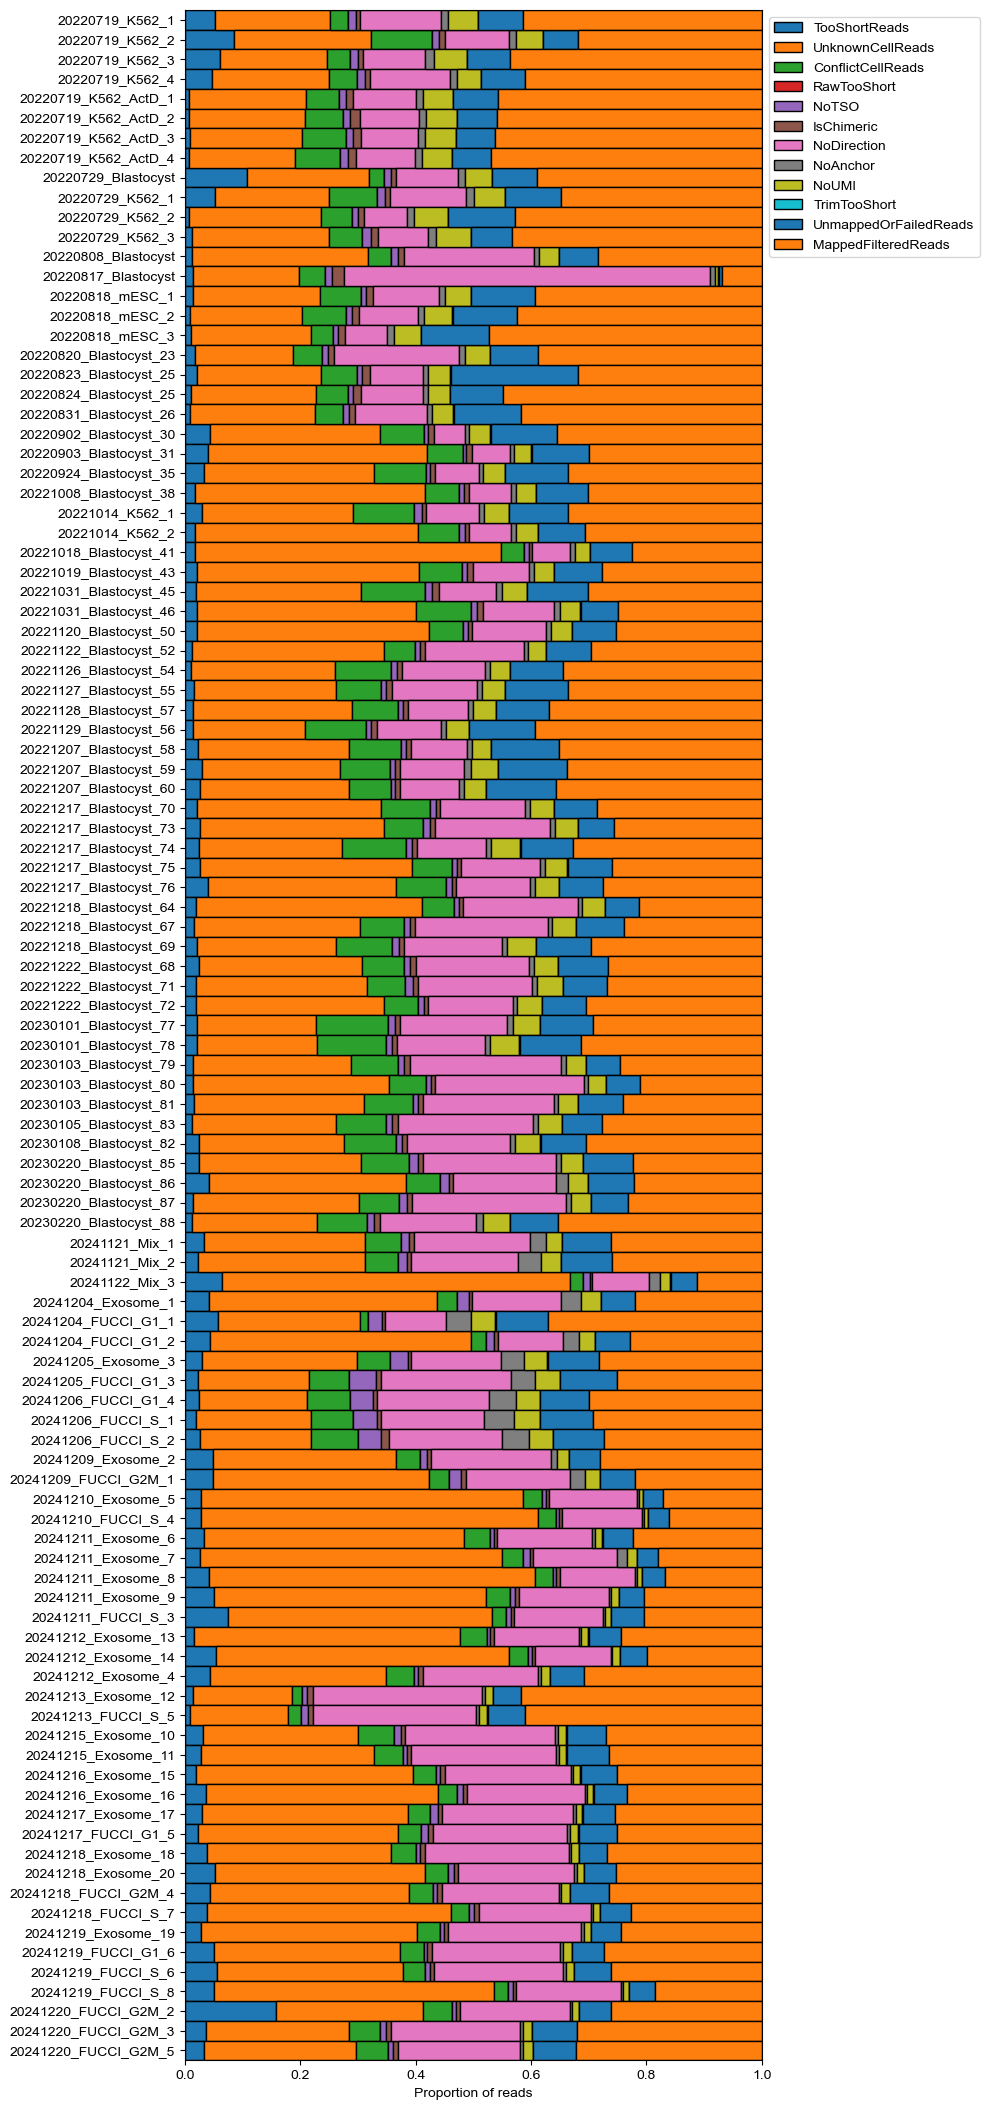

In [25]:
ys = np.arange(len(m))[::-1]
xs0 = np.zeros(len(m))
plt.figure(figsize=(10, 0.2 * (len(m) + 2)))
columns = [
    "TooShortReads", "UnknownCellReads", "ConflictCellReads", 
    "RawTooShort", "NoTSO", "IsChimeric", "NoDirection", "NoAnchor", "NoUMI", "TrimTooShort",
    "UnmappedOrFailedReads", "MappedFilteredReads",
]
for c in columns:
    xs = m[c]/m["TotalReads"]
    plt.barh(ys, xs, left=xs0, height=1, edgecolor="black", lw=1, label=c)
    xs0 += xs
plt.yticks(ys, m.index)
plt.xlim(0, 1)
plt.ylim(-0.5, max(ys) + 0.5)
plt.xlabel("Proportion of reads")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig("figures/proportion_of_reads_in_run.pdf")

Mean: 31.2008%
Median: 29.8559%


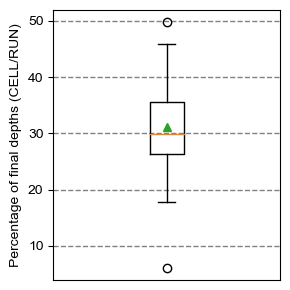

In [26]:
vs = m["CellBasesRatio"] * 100
vs = vs[~np.isnan(vs)]
print("Mean: %.4f%%" % np.mean(vs))
print("Median: %.4f%%" % np.median(vs))
plt.figure(figsize=(3, 3))
plt.boxplot(vs, showmeans=True)
plt.xticks([])
plt.ylabel("Percentage of final depths (CELL/RUN)")
# plt.ylim(0, 50)
plt.grid(axis="y", lw=1, ls="--", color="grey")
plt.tight_layout()
plt.show()